In [1]:
import json
import os
import pandas as pd

In [2]:

files = [
    "datasets/problem.json",
    "datasets/student-problem-middle.json"
]
base_path = "/Users/muazalbaghdadi/Documents/Work/Reasearch/UDST/Gamification/MOOCRadar"

In [3]:
df_problems = pd.read_json(os.path.join(base_path, files[0]), lines=True)

# Loading Middle to DF
file_path = os.path.join(base_path, files[1])
# Load and flatten the nested JSON sequences
with open(file_path, "r", encoding="utf-8") as f:
    student_data = json.load(f)
# Flatten the nested "seq" list for each student
df_middle = pd.json_normalize(student_data, record_path="seq")

In [4]:
print('df_problems info and head')
df_problems.info()
df_problems.head()

df_problems info and head
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9383 entries, 0 to 9382
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   problem_id           9383 non-null   object
 1   exercise_id          9383 non-null   object
 2   course_id            9383 non-null   object
 3   detail               9383 non-null   object
 4   knowledge_type       9383 non-null   int64 
 5   cognitive_dimension  9383 non-null   int64 
 6   concepts             9383 non-null   object
dtypes: int64(2), object(5)
memory usage: 513.3+ KB


,problem_id,exercise_id,course_id,detail,knowledge_type,cognitive_dimension,concepts
0,Pm_2046133,Ex_1641736,C_674920,"{'problem_id': 2046133, 'title': '第一章作业', 'con...",2,4,"[经济发展逻辑, 逻辑学]"
1,Pm_2046134,Ex_1641736,C_674920,"{'problem_id': 2046134, 'title': '第一章作业', 'con...",2,2,"[希腊语, 逻辑]"
2,Pm_2046135,Ex_1641736,C_674920,"{'problem_id': 2046135, 'title': '第一章作业', 'con...",2,2,"[逻辑, 推理]"
3,Pm_2046136,Ex_1641736,C_674920,"{'problem_id': 2046136, 'title': '第一章作业', 'con...",2,2,"[演绎推理, 推理, 结论]"
4,Pm_2046137,Ex_1641736,C_674920,"{'problem_id': 2046137, 'title': '第一章作业', 'con...",2,2,"[命题, 有效推理形式]"


In [5]:
print('df_problems info and head')
df_middle.info()
df_middle.head()

df_problems info and head
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898933 entries, 0 to 898932
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   log_id       898933 non-null  object 
 1   problem_id   898933 non-null  object 
 2   user_id      898933 non-null  object 
 3   is_correct   898933 non-null  int64  
 4   attempts     898933 non-null  int64  
 5   score        355086 non-null  float64
 6   submit_time  898933 non-null  object 
 7   skill_id     898933 non-null  object 
 8   exercise_id  898933 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 61.7+ MB


,log_id,problem_id,user_id,is_correct,attempts,score,submit_time,skill_id,exercise_id
0,1002476_5940094,Pm_668265,U_1002476,1,1,NaN,2020-12-13 12:02:59,Ex_535149,Ex_535149
1,1002476_5940096,Pm_668266,U_1002476,1,1,NaN,2020-12-13 12:03:11,Ex_535149,Ex_535149
2,1002476_5940097,Pm_668267,U_1002476,1,1,NaN,2020-12-13 12:03:18,Ex_535149,Ex_535149
3,1002476_5940102,Pm_668268,U_1002476,1,1,NaN,2020-12-13 12:11:10,Ex_535150,Ex_535150
4,1002476_5940103,Pm_668269,U_1002476,1,1,NaN,2020-12-13 12:11:21,Ex_535150,Ex_535150


# Data Aggregation.

In [6]:
# 1. Merge the interaction logs with the problem metadata
df_merged = pd.merge(
    df_middle, 
    df_problems, 
    on=['problem_id', 'exercise_id'], 
    how='left'
)

In [7]:
# 2. Convert 'submit_time' from string to a datetime object
# (This is mandatory for calculating the Temporal Features in Phase 2)
df_merged['submit_time'] = pd.to_datetime(df_merged['submit_time'])

In [8]:
# 3. Sort the data chronologically per student
# (Crucial so that 'time between attempts' and 'course jumping' calculate in the right order)
df_merged = df_merged.sort_values(by=['user_id', 'submit_time']).reset_index(drop=True)

In [11]:
# Verify the merge
print("Merged Data Shape:", df_merged.shape)
print("\nColumns available for Feature Engineering:")
print(df_merged.columns.tolist())

Merged Data Shape: (898933, 14)

Columns available for Feature Engineering:
['log_id', 'problem_id', 'user_id', 'is_correct', 'attempts', 'score', 'submit_time', 'skill_id', 'exercise_id', 'course_id', 'detail', 'knowledge_type', 'cognitive_dimension', 'concepts']


# Phase 2: Behavioral Feature Engineering.

In [12]:
import numpy as np

In [13]:
print("Engineering behavioral features...")

# --- PRE-COMPUTATIONS ---
# Calculate time gap between actions for each user
df_merged['time_diff'] = df_merged.groupby('user_id')['submit_time'].diff().dt.total_seconds()

# Calculate "course jumps" (when a user switches to a different exercise)
df_merged['exercise_jump'] = (df_merged.groupby('user_id')['exercise_id'].shift() != df_merged['exercise_id']).astype(int)

# Identify high cognitive tasks (Bloom's level 4, 5, 6)
df_merged['is_high_cog'] = df_merged['cognitive_dimension'] >= 4

Engineering behavioral features...


# --- AGGREGATION ---

In [21]:

# Group by user to create the student-centric dataframe
df_aggregated = df_merged.groupby('user_id').agg(
    
    # 1. Temporal Features
    median_time_between_attempts=('time_diff', 'median'),
    active_days_count=('submit_time', lambda x: x.dt.date.nunique()),
    
    # 2. Effort & Tenacity Features
    total_attempts=('attempts', 'sum'),
    unique_problems=('problem_id', 'nunique'),
    abandonment_count=('is_correct', lambda x: (x == 0).sum()), # Count of failed interactions
    
    # 3. Cognitive & Strategy Features
    avg_cognitive_dimension=('cognitive_dimension', 'mean'),
    score_maximization_ratio=('score', lambda x: (x == 1.0).mean()), # How often they get a perfect score
    
    # 4. Exploration Features
    course_jumping_index=('exercise_jump', 'sum')
).reset_index()



# --- POST-COMPUTATIONS (Ratios & Adjustments) ---


In [22]:

# Adjust jumps (subtract 1 because the very first exercise shouldn't count as a jump)
df_aggregated['course_jumping_index'] = np.maximum(0, df_aggregated['course_jumping_index'] - 1)

# Average attempts per problem (Effort)
df_aggregated['avg_attempts_per_problem'] = df_aggregated['total_attempts'] / df_aggregated['unique_problems']

# Abandonment Rate (Percentage of interactions that ended in failure)
df_aggregated['abandonment_rate'] = df_aggregated['abandonment_count'] / df_aggregated['total_attempts']

# Drop intermediate columns we used for math
df_aggregated = df_aggregated.drop(columns=['total_attempts', 'unique_problems', 'abandonment_count'])

# Fill any NaN values (e.g., users with only 1 interaction won't have a 'time_diff')
df_aggregated = df_aggregated.fillna(0)

print("Student-Centric Hexad dataset created!")
print("Shape:", df_aggregated.shape)
print(df_aggregated.head())

Student-Centric Hexad dataset created!
Shape: (14224, 8)
      user_id  median_time_between_attempts  active_days_count  \
0   U_1002476                          29.5                  1   
1  U_10032370                          64.0                  7   
2   U_1006467                          48.0                  7   
3   U_1006581                         209.0                  7   
4   U_1007135                          39.0                  1   

   avg_cognitive_dimension  score_maximization_ratio  course_jumping_index  \
0                 1.960000                  0.000000                    11   
1                 3.000000                  0.000000                     8   
2                 2.114286                  0.828571                    33   
3                 2.114286                  0.842857                    34   
4                 1.571429                  0.285714                     7   

   avg_attempts_per_problem  abandonment_rate  
0                       1.0  

In [24]:
df_aggregated.dtypes

user_id                          object
median_time_between_attempts    float64
active_days_count                 int64
avg_cognitive_dimension         float64
score_maximization_ratio        float64
course_jumping_index              int64
avg_attempts_per_problem        float64
abandonment_rate                float64
dtype: object

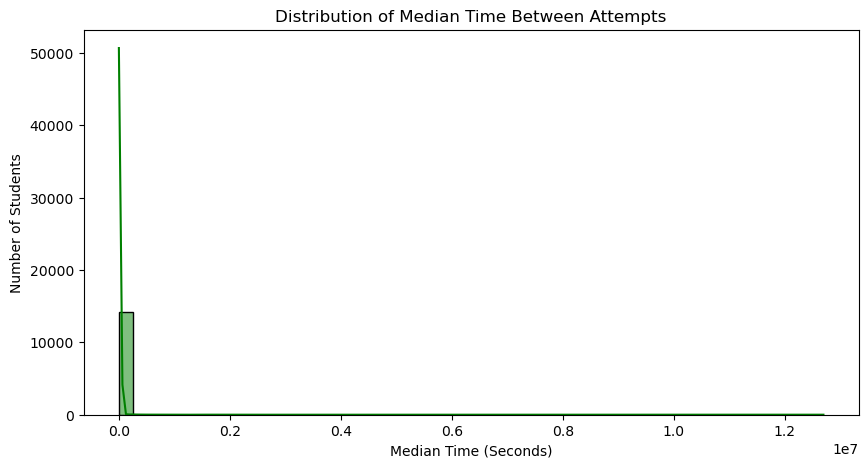

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=df_aggregated, x='median_time_between_attempts', bins=50, kde=True, color='green')

plt.title('Distribution of Median Time Between Attempts')
plt.xlabel('Median Time (Seconds)')
plt.ylabel('Number of Students')
plt.show()

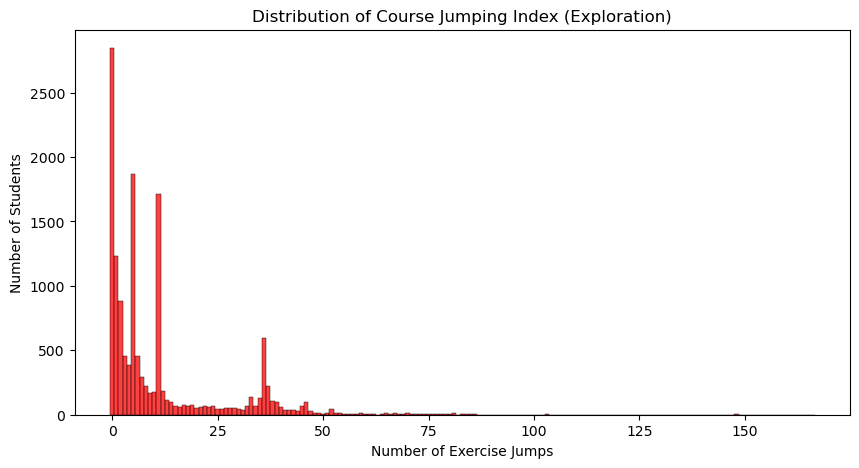

In [34]:

plt.figure(figsize=(10, 5))
sns.histplot(data=df_aggregated, x='course_jumping_index', discrete=True, color='red')

plt.title('Distribution of Course Jumping Index (Exploration)')
plt.xlabel('Number of Exercise Jumps')
plt.ylabel('Number of Students')
plt.show()

# Preprocessing

In [27]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Set user_id as index so it's not treated as a clustering feature
df_features = df_aggregated.set_index('user_id').copy()

# 2. Log-transform highly skewed features
# (Adding 1 to avoid log(0))
df_features['median_time_between_attempts'] = np.log1p(df_features['median_time_between_attempts'])
df_features['course_jumping_index'] = np.log1p(df_features['course_jumping_index'])



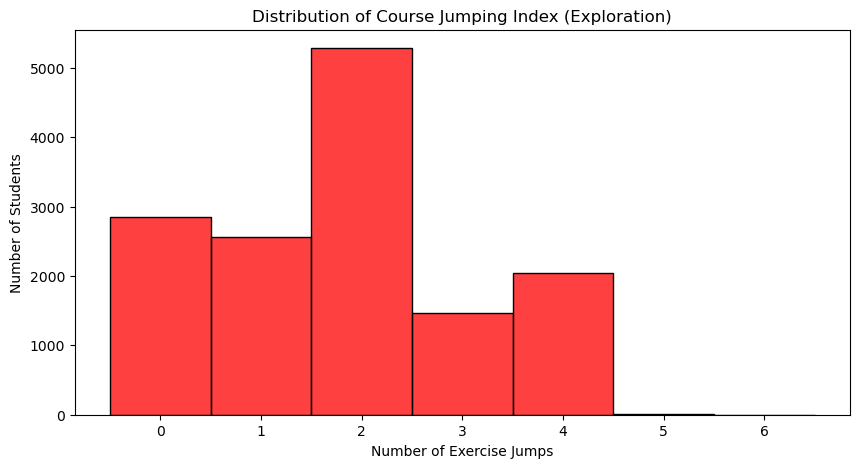

In [35]:

plt.figure(figsize=(10, 5))
sns.histplot(data=df_features, x='course_jumping_index', discrete=True, color='red')

plt.title('Distribution of Course Jumping Index (Exploration)')
plt.xlabel('Number of Exercise Jumps')
plt.ylabel('Number of Students')
plt.show()

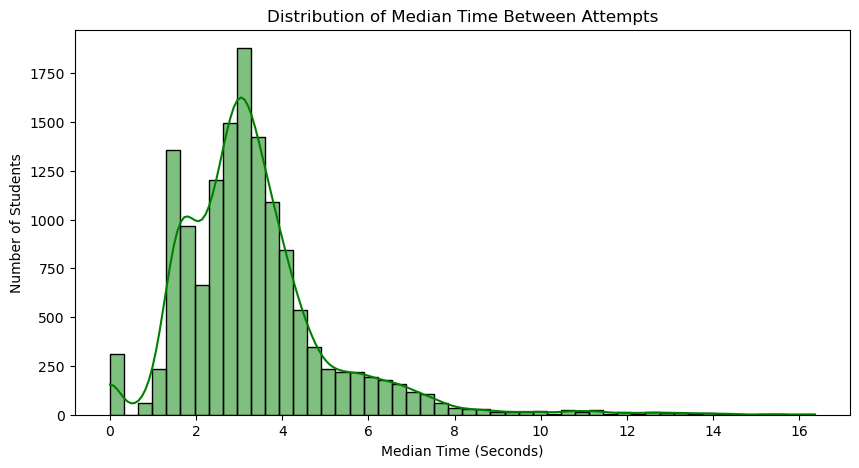

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_features, x='median_time_between_attempts', bins=50, kde=True, color='green')

plt.title('Distribution of Median Time Between Attempts')
plt.xlabel('Median Time (Seconds)')
plt.ylabel('Number of Students')
plt.show()

# Standardize all features

In [36]:
# 3. Standardize all features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_features)


In [38]:
# Convert scaled array back to a DataFrame for easier inspection
df_features_scaled = pd.DataFrame(
    features_scaled, 
    index=df_features.index, 
    columns=df_features.columns
)

print("Preprocessed features preview:")
print(df_features_scaled.head())

Preprocessed features preview:
            median_time_between_attempts  active_days_count  \
user_id                                                       
U_1002476                       0.053386          -0.565779   
U_10032370                      0.475661           1.079452   
U_1006467                       0.317967           1.079452   
U_1006581                       1.130129           1.079452   
U_1007135                       0.204710          -0.565779   

            avg_cognitive_dimension  score_maximization_ratio  \
user_id                                                         
U_1002476                 -0.607029                 -0.909577   
U_10032370                 1.615771                 -0.909577   
U_1006467                 -0.277273                  1.552396   
U_1006581                 -0.277273                  1.594844   
U_1007135                 -1.437525                 -0.060620   

            course_jumping_index  avg_attempts_per_problem  abandonment

# Check for Multicollinearity (Feature Correlation)

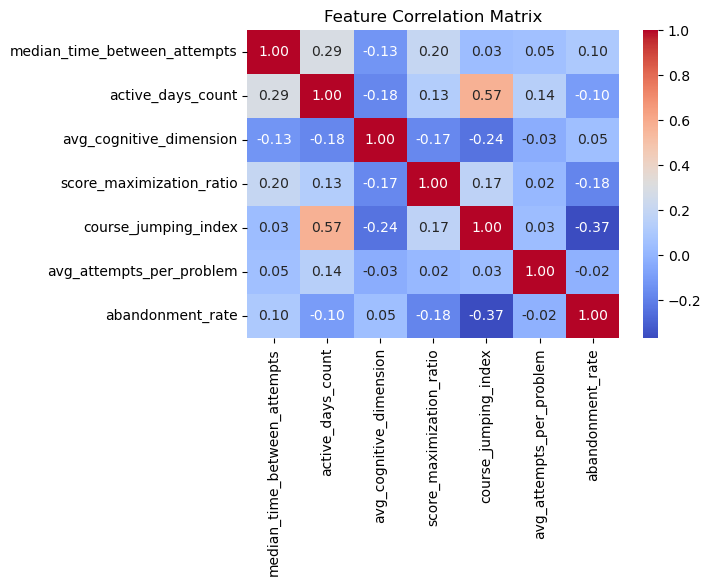

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Calculating the elbow curve

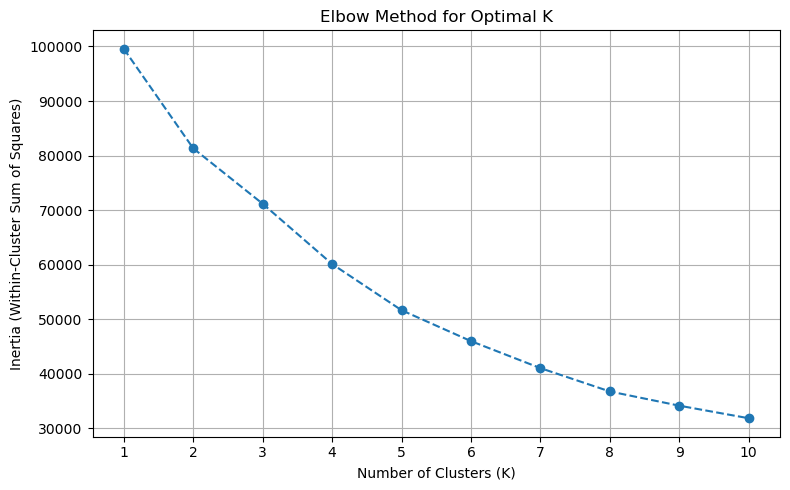

In [48]:
from sklearn.cluster import KMeans

# Calculate inertia for K from 1 to 10
k_range_elbow = range(1, 11)
inertias = []
for k in k_range_elbow:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_features_scaled)
    inertias.append(kmeans.inertia_)
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range_elbow, inertias, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range_elbow)
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculating the Silhouette score

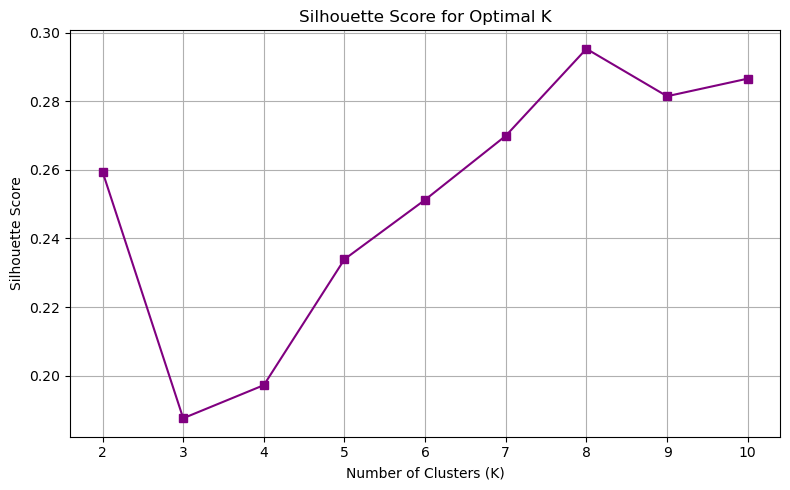

In [47]:
from sklearn.metrics import silhouette_score
# Calculate silhouette score for K from 2 to 10
k_range_silhouette = range(2, 11)
silhouette_scores = []
for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_features_scaled)
    
    # Using a subset of 5,000 samples for fast computation
    score = silhouette_score(
        df_features_scaled, 
        kmeans.labels_, 
        sample_size=5000, 
        random_state=42
    )
    silhouette_scores.append(score)
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range_silhouette, silhouette_scores, marker='s', color='purple', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.tight_layout()
plt.show()

# Clustering With K-means

In [99]:

# 1. Define the number of clusters (adjust based on Elbow/Silhouette results)
optimal_k = 8 

# 2. Fit K-Means on the standardized features
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_features_scaled)

# 3. Assign the labels back to the original aggregated DataFrame and scaled DataFrame
df_aggregated['cluster'] = cluster_labels
df_features_scaled['cluster'] = cluster_labels

print(f"Data successfully clustered into {optimal_k} groups!")
print(df_aggregated['cluster'].value_counts().sort_index())



Data successfully clustered into 8 groups!
cluster
0    2230
1    4442
2    2256
3      43
4     863
5    1075
6     782
7    2533
Name: count, dtype: int64


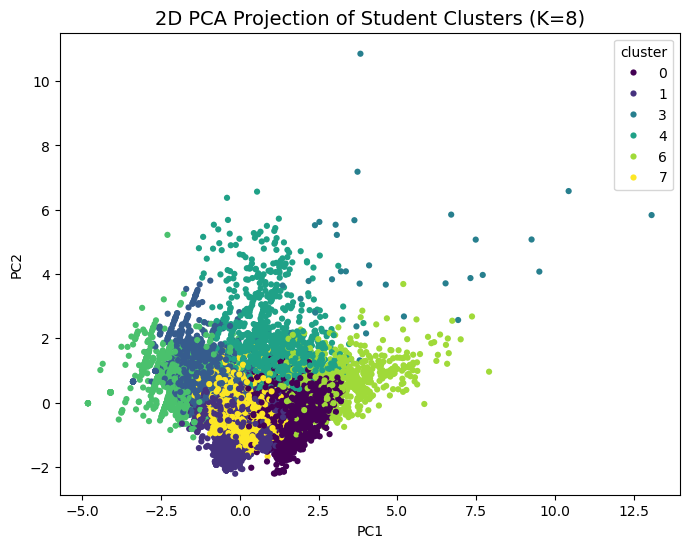

In [100]:
from sklearn.decomposition import PCA

# 1. Separate features for PCA (ensure 'cluster' label is excluded if present)
features_for_pca = df_features_scaled.drop(columns=['cluster'], errors='ignore')

# 2. Apply PCA to reduce dimensions from 7 to 2
pca = PCA(n_components=2)
pca_results = pca.fit_transform(features_for_pca)

# 3. Create a temporary DataFrame for plotting
df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['cluster'] = cluster_labels  # Using the labels from K-Means

# 4. Plot the 2D Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    palette='viridis',  # Clean, distinct colors for each cluster
    data=df_pca,
    edgecolor='none', # Removes borders around dots for a cleaner visual
    s=20              # Marker size
)
plt.title(f'2D PCA Projection of Student Clusters (K={optimal_k})', fontsize=14)
plt.show()


# CLustering with DBSCAN

In [85]:
from sklearn.cluster import DBSCAN

# 1. Define DBSCAN parameters
# eps: Max distance between two samples to be in the same neighborhood (start with 0.5 - 1.5 for scaled features)
# min_samples: Min number of samples in a neighborhood to define a cluster core point
eps_val = 0.5
min_samples_val = 15

# Ensure we drop any existing 'cluster' column from previous runs before fitting
features_to_fit = df_features_scaled.drop(columns=['cluster'], errors='ignore')

# 2. Fit DBSCAN on the standardized features
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
cluster_labels = dbscan.fit_predict(features_to_fit)

# 3. Assign the labels back to the original aggregated DataFrame and scaled DataFrame
df_aggregated['cluster'] = cluster_labels
df_features_scaled['cluster'] = cluster_labels

# 4. Analyze the DBSCAN clustering results
n_clusters_ = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise_ = list(cluster_labels).count(-1)

print("DBSCAN clustering completed successfully!")
print(f"Estimated number of clusters (excluding noise): {n_clusters_}")
print(f"Estimated number of noise/outlier points: {n_noise_} ({n_noise_ / len(cluster_labels) * 100:.2f}% of data)")
print("-" * 50)
print("Cluster size distribution:")
print(df_aggregated['cluster'].value_counts().sort_index())


DBSCAN clustering completed successfully!
Estimated number of clusters (excluding noise): 41
Estimated number of noise/outlier points: 3965 (27.88% of data)
--------------------------------------------------
Cluster size distribution:
cluster
-1     3965
 0     1401
 1       94
 2     5429
 3       58
 4      555
 5       43
 6       49
 7       90
 8       43
 9      739
 10      38
 11      62
 12     113
 13     206
 14      54
 15      18
 16      35
 17     196
 18      25
 19      27
 20      65
 21      25
 22      56
 23      26
 24     400
 25      44
 26      20
 27      29
 28      18
 29      31
 30      16
 31      47
 32      18
 33      38
 34      27
 35      26
 36      36
 37      15
 38      16
 39      16
 40      15
Name: count, dtype: int64


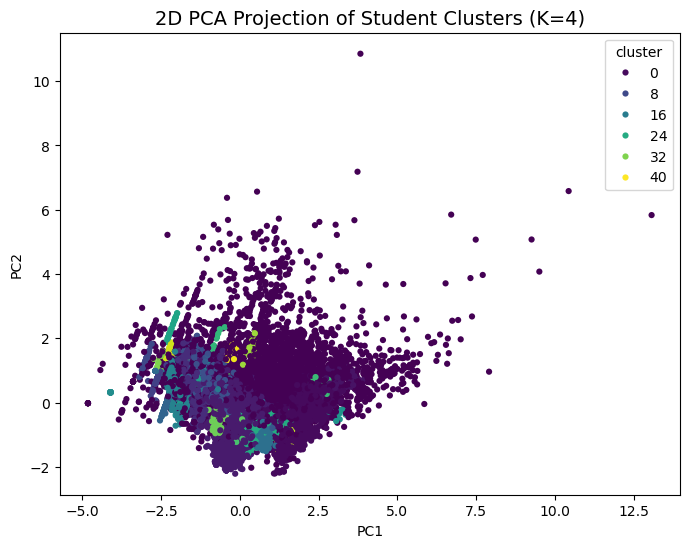

In [86]:
# 1. Separate features for PCA (ensure 'cluster' label is excluded if present)
features_for_pca = df_features_scaled.drop(columns=['cluster'], errors='ignore')

# 2. Apply PCA to reduce dimensions from 7 to 2
pca = PCA(n_components=2)
pca_results = pca.fit_transform(features_for_pca)

# 3. Create a temporary DataFrame for plotting
df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['cluster'] = cluster_labels  # Using the labels from K-Means

# 4. Plot the 2D Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    palette='viridis',  # Clean, distinct colors for each cluster
    data=df_pca,
    edgecolor='none', # Removes borders around dots for a cleaner visual
    s=20              # Marker size
)
plt.title(f'2D PCA Projection of Student Clusters (K={optimal_k})', fontsize=14)
plt.show()


# Claculating the top defining features for each cluster

In [102]:
# 1. Create a copy and ensure 'user_id' is set as the index (if present as a column)
student_data = df_aggregated.copy()
if 'user_id' in student_data.columns:
    student_data = student_data.set_index('user_id')

# 2. Calculate the mean value for each feature per cluster
cluster_means = student_data.groupby('cluster').mean()

# 3. Calculate the global mean and standard deviation for each feature across the whole dataset
# Drop the 'cluster' column to only get feature statistics
features_only = student_data.drop('cluster', axis=1)
global_mean = features_only.mean()
global_std = features_only.std()

# 4. Calculate Z-scores (how many standard deviations away from the global mean)
z_scores = (cluster_means - global_mean) / global_std

# 5. List the most important features for each cluster
print("Top defining features for each cluster (by deviation from average):")
print("-" * 90)

for cluster_id in sorted(z_scores.index):
    print(f"\nCluster {cluster_id}:")
    
    # Sort features by absolute Z-score (magnitude of difference)
    # Since we have 7 features, displaying them all shows the full profile
    sorted_features = z_scores.loc[cluster_id].abs().sort_values(ascending=False)
    
    for feature_name in sorted_features.index:
        # Get the actual signed Z-score to see if it's high (+) or low (-)
        actual_z = z_scores.loc[cluster_id, feature_name]
        cluster_val = cluster_means.loc[cluster_id, feature_name]
        global_val = global_mean[feature_name]
        
        direction = "HIGH" if actual_z > 0 else "LOW"
        
        print(f"  - {feature_name:<30}: {direction:<4} (Z-score: {actual_z:>5.2f}) | Cluster Avg: {cluster_val:>10.2f} vs Global Avg: {global_val:>10.2f}")


Top defining features for each cluster (by deviation from average):
------------------------------------------------------------------------------------------

Cluster 0:
  - course_jumping_index          : HIGH (Z-score:  1.26) | Cluster Avg:      29.96 vs Global Avg:      11.24
  - score_maximization_ratio      : HIGH (Z-score:  0.98) | Cluster Avg:       0.64 vs Global Avg:       0.31
  - avg_cognitive_dimension       : LOW  (Z-score: -0.61) | Cluster Avg:       1.96 vs Global Avg:       2.24
  - active_days_count             : HIGH (Z-score:  0.41) | Cluster Avg:       4.56 vs Global Avg:       3.06
  - abandonment_rate              : LOW  (Z-score: -0.27) | Cluster Avg:       0.22 vs Global Avg:       0.28
  - avg_attempts_per_problem      : LOW  (Z-score: -0.06) | Cluster Avg:       1.00 vs Global Avg:       1.00
  - median_time_between_attempts  : LOW  (Z-score: -0.04) | Cluster Avg:      52.93 vs Global Avg:    7448.04

Cluster 1:
  - score_maximization_ratio      : LOW  (Z-sco